## Correlation and ScatterPlots

In [1]:
cd Downloads

C:\Users\abuel\Downloads


C:\Users\abuel\anaconda3\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Preliminarties

In [2]:
import pandas as pd
con = pd.read_csv('ConcreteStrength.csv')
con

,No,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,Compressive Strength (28-day)(Mpa)
0,1,273.0,82.0,105.0,210.0,9.0,904.0,680.0,34.990
1,2,163.0,149.0,191.0,180.0,12.0,843.0,746.0,32.272
2,3,162.0,148.0,191.0,179.0,16.0,840.0,743.0,35.450
3,4,162.0,148.0,190.0,179.0,19.0,838.0,741.0,42.080
4,5,154.0,112.0,144.0,220.0,10.0,923.0,658.0,26.820
...,...,...,...,...,...,...,...,...,...
98,99,248.3,101.0,239.1,168.9,7.7,954.2,640.6,49.970
99,100,248.0,101.0,239.9,169.1,7.7,949.9,644.1,50.230
100,101,258.8,88.0,239.6,175.3,7.6,938.9,646.0,43.461
101,102,297.1,40.9,239.9,194.0,7.5,908.9,651.8,44.639


## Rename Columns

Recall the the column names in the “ConcreteStrength” file are problematic: they are too long to type repeatedly, have spaces, and include special characters like “.”. Although we could change the name of the columns in the underlying spreadsheet before importing, it is generally more practical/less work/less risk to leave the organization’s spreadsheets and files as they are and write some code to fix things prior to analysis. In this way, you do not have to start over when an updated version of the data is handed to you.

Let’s start by listing the column names. A Pandas DataFrame object exposes a list of columns through the columns property. Here I use the list() type conversion method to convert the results to a simple list (which prints nicer):

In [4]:
list(con.columns)

['No',
 'Cement',
 'Slag',
 'Fly ash',
 'Water',
 'SP',
 'Coarse Aggr.',
 'Fine Aggr.',
 'Compressive Strength (28-day)(Mpa)']

The rename() method for data frames is straightforward. Here I define a standard Python dictionary (of the form {key1: value1, key2: value2, … }) and assign it to the “columns” axis. Remember that the inplace=True argument is required if we want to make changes to the underlying data frame.

In [5]:
con.rename(columns={'Fly ash': 'FlyAsh', 'Coarse Aggr.': "CoarseAgg",
                    'Fine Aggr.': 'FineAgg', 'Air Entrainment': 'AirEntrain', 
                    'Compressive Strength (28-day)(Mpa)': 'Strength'}, inplace=True)
con.head()

,No,Cement,Slag,FlyAsh,Water,SP,CoarseAgg,FineAgg,Strength
0,1,273.0,82.0,105.0,210.0,9.0,904.0,680.0,34.990
1,2,163.0,149.0,191.0,180.0,12.0,843.0,746.0,32.272
2,3,162.0,148.0,191.0,179.0,16.0,840.0,743.0,35.450
3,4,162.0,148.0,190.0,179.0,19.0,838.0,741.0,42.080
4,5,154.0,112.0,144.0,220.0,10.0,923.0,658.0,26.820


## ScatterPlots

Scatterplots are a fundamental graph type—much less complicated than histograms and boxplots. As such, we might use the Mathplotlib library instead of the Seaborn library. But since we have already used Seaborn, I will stick with it here. Just know that there are many ways to create scatterplots and other basic graphs in Python.

To create a bare-bones scatterplot, we must do four things:

Load the seaborn library

Specify the source data frame

Set the x axis, which is generally the name of a predictor/independent variable

Set the y axis, which is generally the name of a response/dependent variable

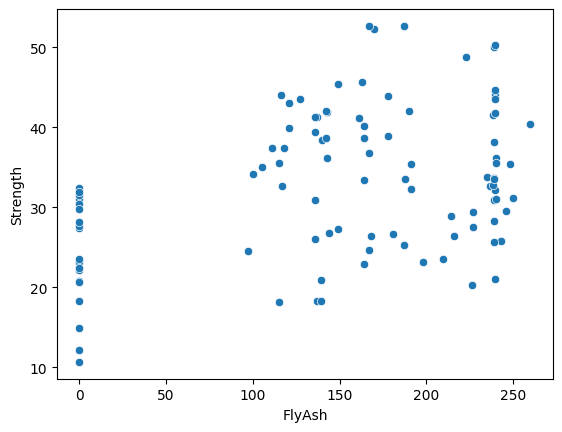

In [7]:
import seaborn as sns
sns.scatterplot(x="FlyAsh", y="Strength", data=con);

## Add some labels

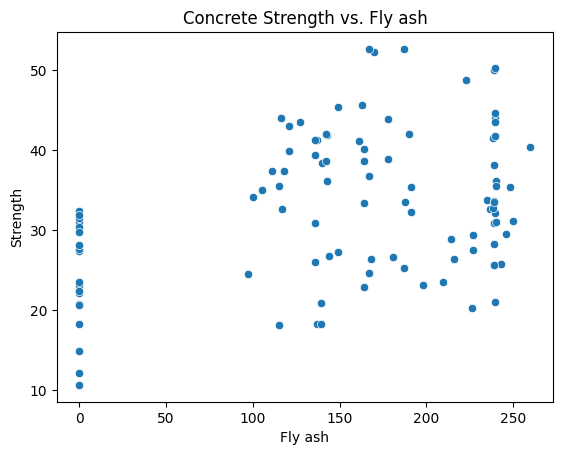

In [8]:
ax = sns.scatterplot(x="FlyAsh", y="Strength", data=con)
ax.set_title("Concrete Strength vs. Fly ash")
ax.set_xlabel("Fly ash");

## Add Line of best Fit

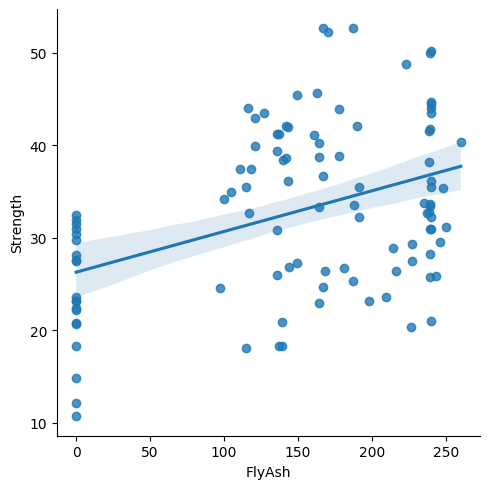

In [9]:
sns.lmplot(x="FlyAsh", y="Strength", data=con);

## Coefficient of Correlation

A correlation coefficient (typically denoted r) is a single number that describes the extent of the linear relationship between two variables. A value of +1 indicates perfect linearity (the two variables move together, like “height in inches” and “height in centimeters”). A value of r = 0 indicates no correlation (the variables are independent) and r = -1 indicates the variables are inversely correlated (an increase in one variable is associated with a decrease in the other).

Like many other statistics (measures derived from raw data), there are slightly different ways to calculate the correlation coefficient that are more or less sensitive to outliers and other characteristics of the data. The most common measure is the Pearson correlation coefficient. The Scipy library provides a method called pearsonr() (Pearson’s r).

In [10]:
from scipy import stats
stats.pearsonr(con['Strength'], con['FlyAsh'])

PearsonRResult(statistic=np.float64(0.4063870105954507), pvalue=np.float64(2.0500713273946017e-05))

Again, it is not the prettiest result. But, if we were so inclined, we could write the results to a data frame and apply whatever formatting in Python we wanted to. In this form, however, we get two numbers:

Pearson’s r (0,4063—same as we got in Excel, R, etc.)

A p-value. This is the probability that the true value of r is zero (no correlation).

We conclude based on this that there is weak linear relationship between concrete strength and fly ash but not so weak that we should conclude the variables are uncorrelated. In other words, it seems that fly ash does have some influence on concrete strength.

Of course, correlation does not imply causality. It is equally correct, based on the value of r, to say that concrete strength has some influence on the amount of fly ash in the mix. But hopefully we are worldly enough to know something about mixing up a batch of concrete and can generally infer causality, or at least directionality. That is, we use our domain knowledge to help interpret statistical results.



## Correlation Matrix

A correlation matrix is a handy way to calculate the pairwise correlation coefficients between two or more (numeric) variables. The Pandas data frame has this functionality built-in to its corr() method, which I have wrapped inside the round() method to keep things tidy. Notice that every correlation matrix is symmetrical: the correlation of “Cement” with “Slag” is the same as the correlation of “Slag” with “Cement” (-0.24). Thus, the top (or bottom, depending on your preferences) of every correlation matrix is redundant. The correlation between each variable and itself is 1.0, hence the diagonal.

In [12]:
cormat = con.corr()
round(cormat,2)

,No,Cement,Slag,FlyAsh,Water,SP,CoarseAgg,FineAgg,Strength
No,1.00,-0.03,-0.08,0.34,-0.14,-0.33,0.22,-0.31,0.19
Cement,-0.03,1.00,-0.24,-0.49,0.22,-0.11,-0.31,0.06,0.46
Slag,-0.08,-0.24,1.00,-0.32,-0.03,0.31,-0.22,-0.18,-0.33
FlyAsh,0.34,-0.49,-0.32,1.00,-0.24,-0.14,0.17,-0.28,0.41
Water,-0.14,0.22,-0.03,-0.24,1.00,-0.16,-0.60,0.11,-0.22
SP,-0.33,-0.11,0.31,-0.14,-0.16,1.00,-0.10,0.06,-0.02
CoarseAgg,0.22,-0.31,-0.22,0.17,-0.60,-0.10,1.00,-0.49,-0.15
FineAgg,-0.31,0.06,-0.18,-0.28,0.11,0.06,-0.49,1.00,-0.17
Strength,0.19,0.46,-0.33,0.41,-0.22,-0.02,-0.15,-0.17,1.00


## Correlation Matrix to heatmap

Python, and its libraries, make lots of things easy. For example, once the correlation matrix is defined (I assigned to the variable cormat above), it can be passed to Seaborn’s heatmap() method to create a heatmap (or headgrid). The basic idea of heatmaps is that they replace numbers with colors of varying shades, as indicated by the scale on the right. Cells that are lighter have higher values of r. This type of visualization can make it much easier to spot linear relationships between variables than a table of numbers. For example, if I focus on the “Strength” column, I immediately see that “Cement” and “FlyAsh” have the largest positive correlations whereas “Slag” has the large negative correlation.

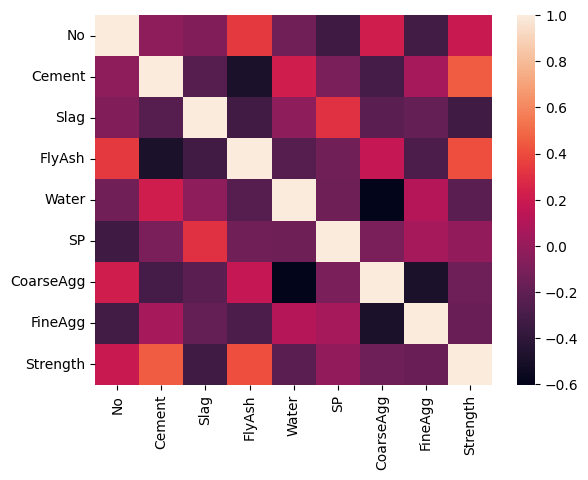

In [13]:
sns.heatmap(cormat);

## Linear Regression

The method we will use to create linear regression models in the Statsmodels library is OLS(). OLS stands for “ordinary least squares”, which means the algorithm finds the best fit line my minimizing the squared residuals (this is “least squares”). The “ordinary” part of the name gives us the sense that the type of linear regression we are seeing here is just the tip of the methodological iceberg. There is a whole world of non-ordinary regression techniques out there intended to address this or that methodological problem or circumstance. But since this is a basic course, we will stick with ordinary least squares.



Recall the general format of the linear regression equation: 
, where 
 is the value of the response variable and 
 is the value of the explanatory variable(s).

If we think about this equation in matrix terms, we see that Y is a 1-dimensional matrix: it is just a single column (or array or vector) of numbers. In our case, this vector corresponds to the compressive strength of different batches of concrete measured in megapascals. The right-hand side of the equation is actually a 2-dimensional matrix: there is one column for our X variable and another column for the constant. We don’t often think about the constant as a column of data, but the Statsmodels library does, which is why we are talking about it.

Creating a linear regression model in Statsmodels thus requires the following steps:

Import the Statsmodels library

Define Y and X matrices. This is optional, but it keeps the OLS() call easier to read

Add a constant column to the X matrix

Call OLS() to define the model

Call fit() to actually estimate the model parameters using the data set (fit the line)

Display the results

Let’s start with the first three steps:

In [14]:
import statsmodels.api as sm
Y = con['Strength']
X = con['FlyAsh']
X.head()

0    105.0
1    191.0
2    191.0
3    190.0
4    144.0
Name: FlyAsh, dtype: float64

We see above that X is a single column of numbers (amount of fly ash in each batch of concrete). The numbers on the left are just the Python index (very row in a Python array has a row number, or index).



## Adding a column for a constant VERY IMPORTANT

We can add another column for the regression constant using Statsmodels add_constant() method:

In [15]:
X = sm.add_constant(X)
X.head()

,const,FlyAsh
0,1.0,105.0
1,1.0,191.0
2,1.0,191.0
3,1.0,190.0
4,1.0,144.0


Notice the difference: the X matrix has been augmented with a column of 1s called “const”. To see why, recall the point of linear regression: to use data to “learn” the parameters of the best-fit line and use the parameters to make predictions. The parameters of a line are its y-intercept and slope. Once we have the y-intercept and slope (
 and 
 in the equation above or b and m in grade 9 math), we can multiply them by the data in the X matrix to get a prediction for Y.

Written out in words for the first row of our data, we get: Concrete strength estimate = 
 x 1 + 
 x 105.0

The “const” column simply provides a placeholder—a bunch of 1s to multiply the constant by. So now we understand why we have to run add_constant().



## Running the Model 

In [16]:
model = sm.OLS(Y, X, missing='drop')
model_result = model.fit()
model_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Strength   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     19.98
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           2.05e-05
Time:                        15:24:35   Log-Likelihood:                -365.58
No. Observations:                 103   AIC:                             735.2
Df Residuals:                     101   BIC:                             740.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.2764      1.691     15.543      0.000      22.923      29.630
FlyAsh         0.0440      0.010      4.470      0.000       0.024       0.064
==============================================================================
Omnibus:                        5.741   Durbin-Watson:                   1.098
Prob(Omnibus):                  0.057   Jarque-Bera (JB):                2.716
Skew:                           0.064   Prob(JB):                        0.257
Kurtosis:                       2.215   Cond. No.                         346.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Lets do some diagnostics

Statsmodels exposes the residuals. That is, keeps an array containing the difference between the observed values Y and the values predicted by the linear model. A fundamental assumption is that the residuals (or “errors”) are random: some big, some some small, some positive, some negative, but overall, the errors are normally distributed around a mean of zero. Anything other than normally distributed residuals indicates a serious problem with the linear model.



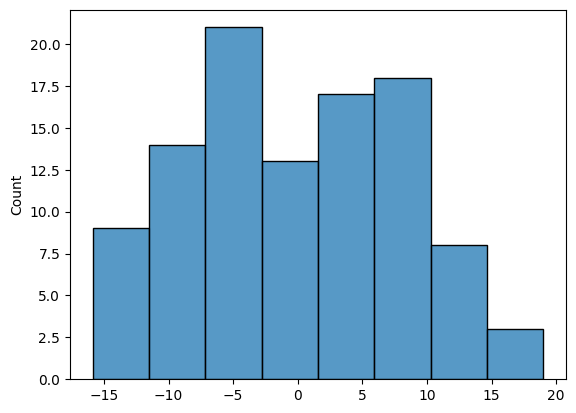

In [17]:
import seaborn as sns
sns.histplot(model_result.resid);

A slightly more useful approach for assessing normality is to compare the kernel density estimate with the curve for the corresponding normal curve. To do this, we generate the normal curve that has the same mean and standard deviation as our observed residual and plot it on top of our residual.

We use a Python trick to assign two values at once: the fit() function returns both the mean and the standard deviation of the best-fit normal distribution.

In [18]:
from scipy import stats
mu, std = stats.norm.fit(model_result.resid)
mu, std

(np.float64(1.1727404376623012e-14), np.float64(8.418278511304978))

We can now re-plot the residuals as a kernel density plot and overlay the normal curve with the same mean and standard deviation:

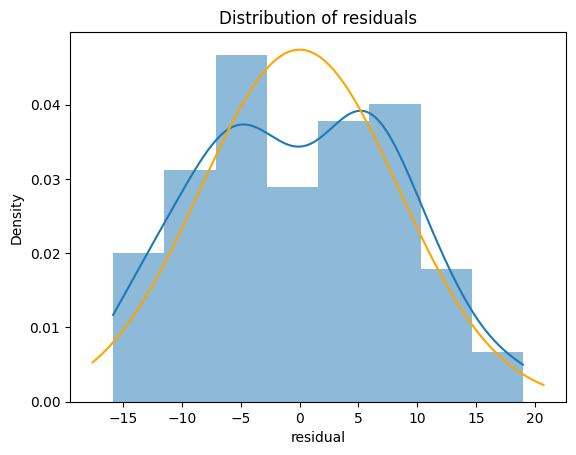

In [19]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
# plot the residuals
sns.histplot(x=model_result.resid, ax=ax, stat="density", linewidth=0, kde=True)
ax.set(title="Distribution of residuals", xlabel="residual")

# plot corresponding normal curve
xmin, xmax = plt.xlim() # the maximum x values from the histogram above
x = np.linspace(xmin, xmax, 100) # generate some x values
p = stats.norm.pdf(x, mu, std) # calculate the y values for the normal curve
sns.lineplot(x=x, y=p, color="orange", ax=ax)
plt.show()

## BoxPlot of residuals

A boxplot is often better when the residuals are highly non-normal. Here we see a reasonable distribution with the mean close to the median (indicating symmetry).

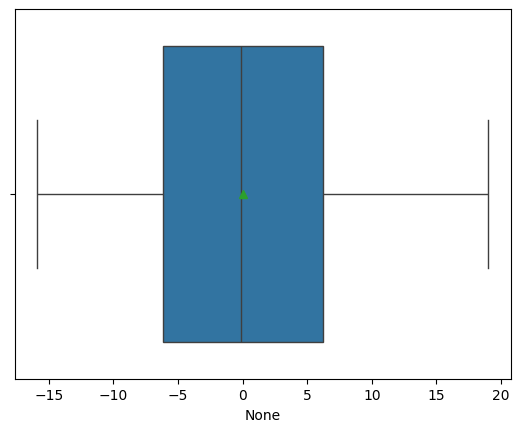

In [21]:
sns.boxplot(x=model_result.resid, showmeans=True);

## Q-Q Plot

A Q-Q plot is a bit more specialized than a histogram or boxplot, so the easiest thing is to use the regression diagnostic plots provided by Statsmodels. How did I know Statsmodels has regression diagnostic plots? I Googled it. These plots are not as attractive as the Seaborn plots, but they are intended primarily for the data analyst. I think it is safe to assume that high-level decision makers will not be asking for Q-Q plots.

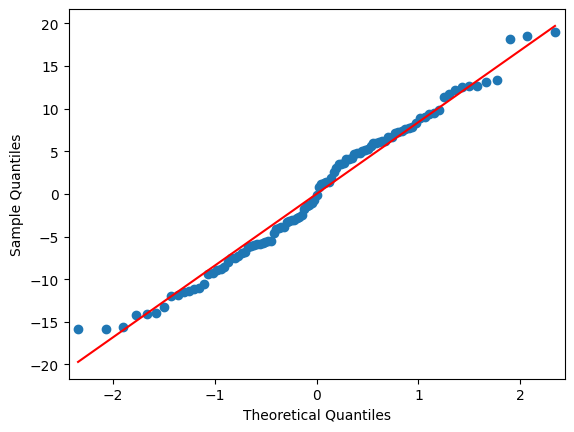

In [22]:
sm.qqplot(model_result.resid, line='s');

## Fit Plot
A fit plot shows predicted values of the response variable versus actual values of Y. If the linear regression model is perfect, the predicted values will exactly equal the observed values and all the data points in a predicted versus actual scatterplot will fall on the 45° diagonal.

The fit plot provided by Statsmodels is okay in the sense that it gives a rough sense of the quality of the model. Since the 
R2 of this model is only 0.165, it should come as no surprise that the fit model is not particularly good.

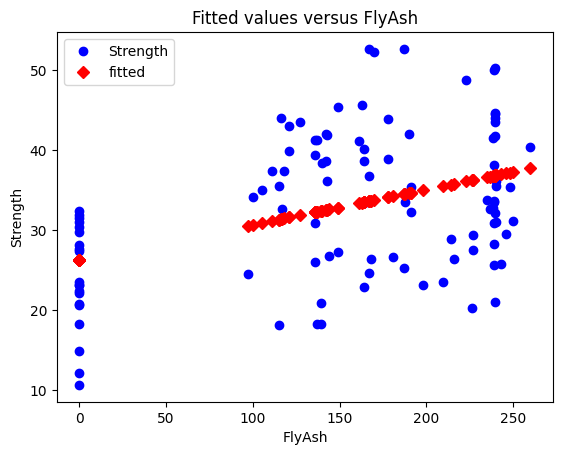

In [23]:
sm.graphics.plot_fit(model_result,1, vlines=False);

## Fit Plot in Seaborn
creating a better fit plot is a bit more work.  The central issue is that the observed and predicted axis must be identical for the reference line to be 45&deg;.  To achieve this, I do the following below:
1. Determine the min and max values for the observed values of _Y_
2. Predict values of _Y_
3. Create a plot showing the observed versus predicted values of _Y_. Save this to an object (in my case `ax`)
4. Modify the chart object so that the two axes share the same minimum and maximum values
5. Generate data on a 45&deg; line and add the reference line to the plot

In [24]:
model_result.fittedvalues

0      30.901424
1      34.689565
2      34.689565
3      34.645517
4      32.619302
         ...    
98     36.808282
99     36.843520
100    36.830306
101    36.843520
102    36.103511
Length: 103, dtype: float64

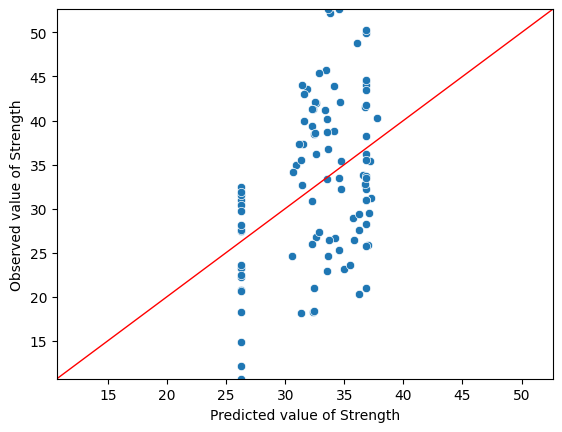

In [25]:
Y_max = Y.max()
Y_min = Y.min()

ax = sns.scatterplot(x=model_result.fittedvalues, y=Y)
ax.set(ylim=(Y_min, Y_max))
ax.set(xlim=(Y_min, Y_max))
ax.set_xlabel("Predicted value of Strength")
ax.set_ylabel("Observed value of Strength")

X_ref = Y_ref = np.linspace(Y_min, Y_max, 100)
plt.plot(X_ref, Y_ref, color='red', linewidth=1)
plt.show()